In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
master = pd.read_csv("../data/cleaned/master_dataset.csv")

In [3]:
master["order_purchase_timestamp"] = pd.to_datetime(
    master["order_purchase_timestamp"]
)

In [4]:
snapshot_date = (
    master["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2018-10-18 17:30:18')

In [6]:
rfm = master.groupby("customer_unique_id").agg(
{
    "order_purchase_timestamp":
    lambda x: (snapshot_date - x.max()).days,

    "order_id":
    "nunique",

    "revenue":
    "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [7]:
rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [8]:
rfm.shape

(96096, 3)

In [9]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [10]:
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [11]:
rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [12]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1
0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1
0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4


In [13]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Recency    96096 non-null  int64   
 1   Frequency  96096 non-null  int64   
 2   Monetary   96096 non-null  float64 
 3   R_score    96096 non-null  category
 4   F_score    96096 non-null  category
 5   M_score    96096 non-null  category
dtypes: category(3), float64(1), int64(2)
memory usage: 3.2+ MB


In [14]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1
0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1
0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4


In [15]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

In [16]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,414
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214


In [17]:
rfm["Segment"] = "Others"

In [18]:
rfm.loc[
    (rfm["R_score"].astype(int) >= 4) &
    (rfm["F_score"].astype(int) >= 4),
    "Segment"
] = "Champions"

In [19]:
rfm.loc[
    (rfm["R_score"].astype(int) >= 3) &
    (rfm["F_score"].astype(int) >= 3) &
    (rfm["Segment"] == "Others"),
    "Segment"
] = "Loyal Customers"

In [20]:
rfm.loc[
    (rfm["R_score"].astype(int) <= 2) &
    (rfm["F_score"].astype(int) >= 4),
    "Segment"
] = "At Risk"

In [21]:
rfm.loc[
    (rfm["R_score"].astype(int) == 1) &
    (rfm["F_score"].astype(int) <= 2),
    "Segment"
] = "Lost Customers"

In [22]:
rfm.loc[
    rfm["Segment"] == "Others",
    "Segment"
] = "Potential Loyalists"

In [23]:
rfm["Segment"].value_counts()

Segment
Potential Loyalists    38371
Loyal Customers        19237
Champions              15453
At Risk                15285
Lost Customers          7750
Name: count, dtype: int64

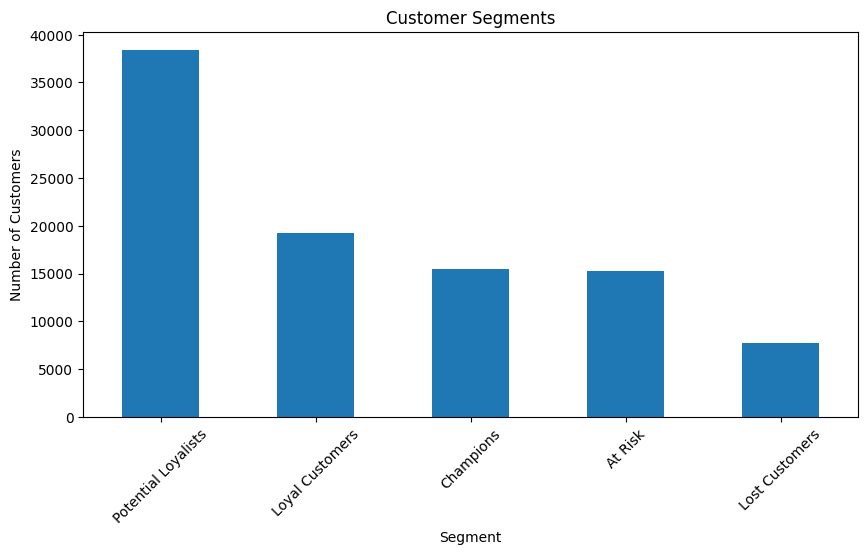

In [24]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

In [25]:
rfm.to_csv(
    "../data/cleaned/rfm_segmentation.csv",
    index=True
)